# Examen entrenamiento de Redes Neuronales Artificiales






*  En este examen hay una parte de programación y dos problemas.
*  Dentro del laboratorio vamos a tener distintas preguntas.
*  Se deberá entregar el fichero en formato ipynb y pdf.
*  En nombre del fichero debe de tener el siguiente formato: NOMBRE_APE1_APE2
*  Se puede utilizar el buscador Google, prácticas anteriores y apuntes de la asignatura.
*  No se puede utilizar ChatGPT
*  Se valorará la originalidad de los experimentos, haciendose mucho hincapié en la calidad de la conclusión de los mismos.
*  Se tendrá en cuenta positivamente aquellos modelos con mejor desempeño.
*  Duración máxima 2 horas.


## **Programación**

Hemos escogido para este laboratorio el dataset fashion-mnist, el motivo es que
es un problema sencillo de entrenar por lo que nuestros modelos deben de entrenarse de una forma rápida.
Lee atentamente los enunciados, en cada pregunta te aparecerá lo que vale.

Descargamos dataset, visualizamos y reshape.

In [30]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping


# Load the fashion-mnist pre-shuffled train data and test data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


x_train shape: (60000, 28, 28) y_train shape: (60000,)
60000 train set
10000 test set
y = 2 Pullover


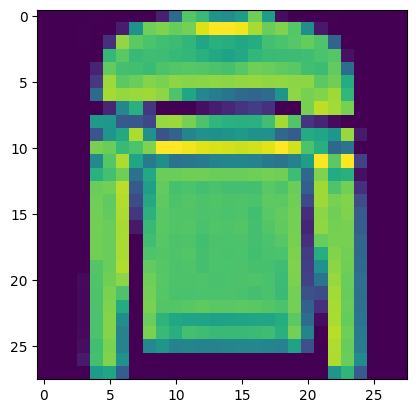

In [31]:
# Print training set shape - note there are 60,000 training data of image size of 28x28, 60,000 train labels)
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)

# Print the number of training and test datasets
print(x_train.shape[0], 'train set')
print(x_test.shape[0], 'test set')

# Define the text labels
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2
                        "Dress",        # index 3
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6
                        "Sneaker",      # index 7
                        "Bag",          # index 8
                        "Ankle boot"]   # index 9

# Image index, you can pick any number between 0 and 59,999
img_index = 5
# y_train contains the lables, ranging from 0 to 9
label_index = y_train[img_index]
# Print the label, for example 2 Pullover
print ("y = " + str(label_index) + " " +(fashion_mnist_labels[label_index]))
# # Show one of the images from the training dataset
plt.imshow(x_train[img_index])

In [32]:
w, h = 28, 28
x_train = x_train.reshape(x_train.shape[0], w, h, 1)
x_test = x_test.reshape(x_test.shape[0], w, h, 1)

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train.shape

(60000, 28, 28, 1)

### **Experimento 1**

#### 1) Elige el tipo de red neuronal óptimo visto en esta asignatura para este tipo de problemas, crea una arquitectura capaz de superar al **80 %** en el val_acurracy.  Justifica el motivo de la elección de esta arquitectura. (1.5 puntos)

In [33]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

# 1. Definición de la arquitectura (CNN)
model = Sequential([
    # Primera capa de extracción de características
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Segunda capa para características más complejas
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Aplanado para conectar con el clasificador final
    Flatten(),

    # Capa densa (clasificador) con Dropout para regularizar y evitar Overfitting
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Capa de salida: 10 neuronas (una por clase) con activación softmax
    Dense(10, activation='softmax')
])

# 2. Compilación del modelo
# Usamos sparse_categorical_crossentropy porque nuestras etiquetas son enteros (0-9), no one-hot arrays.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Configuración del Early Stopping (ya importado en tu código)
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# 4. Entrenamiento del modelo
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop])

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8101 - loss: 0.5252 - val_accuracy: 0.8582 - val_loss: 0.3831
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8712 - loss: 0.3502 - val_accuracy: 0.8748 - val_loss: 0.3368
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8883 - loss: 0.3045 - val_accuracy: 0.8965 - val_loss: 0.2855
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8994 - loss: 0.2713 - val_accuracy: 0.8921 - val_loss: 0.2853
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9080 - loss: 0.2477 - val_accuracy: 0.9031 - val_loss: 0.2590
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9159 - loss: 0.2287 - val_accuracy: 0.9084 - val_loss: 0.2450
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9228 - loss: 0.2113 - val_accuracy: 0.9099 - val_loss: 0.2473
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9262 - loss: 0.1981 - val_accuracy: 0

##### Justificación

Se ha elegido una **Red Neuronal Convolucional (CNN)** en lugar de un Perceptrón Multicapa tradicional (MLP / Red Densa) por los siguientes motivos:

* **Preservación de la estructura espacial:** Un MLP requiere aplanar la imagen de entrada inmediatamente, destruyendo la información espacial (qué píxeles están al lado de cuáles). Las CNN, mediante sus filtros convolucionales, analizan la imagen en 2D y detectan patrones espaciales locales (bordes, texturas y, en capas más profundas, formas como mangas o suelas).
* **Eficiencia de parámetros (Parameter Sharing):** Al usar filtros que se deslizan por toda la imagen, una CNN requiere muchísimos menos pesos entrenables que una capa densa conectada a todos los píxeles. Esto hace que el modelo sea más rápido de entrenar y menos propenso al sobreajuste (*overfitting*).
* **Invarianza a la traslación:** Las operaciones de *Pooling* (como el `MaxPooling2D`) reducen la dimensionalidad y hacen que la red sea capaz de reconocer un zapato o una camiseta independientemente de si está ligeramente desplazado dentro del lienzo de 28x28 píxeles.

#### 2) Durante este laboratorio vamos a realizar una serie de experimentos, por qué necesitamos que realices una estructura de tabla de experimentación y de comparativa por epochs de val_acurracy en la visualización. (0.5 puntos)

##### Justificación

En el desarrollo de redes neuronales, el entrenamiento es un proceso puramente empírico e iterativo. Necesitamos estas herramientas por dos motivos fundamentales:

Tabla de experimentación: Nos permite llevar un registro sistemático y objetivo de todas las pruebas que realizamos (cambios de arquitectura, hiperparámetros, optimizadores). Al consolidar las métricas clave en un solo lugar, evitamos perder el rastro de qué configuración funcionó mejor y facilitamos la toma de decisiones basada en datos, no en intuiciones.

Gráficas comparativas por epoch: El rendimiento final de un modelo no cuenta toda la historia. Las curvas de aprendizaje (Loss y Accuracy por época) son el "electrocardiograma" del entrenamiento. Nos permiten diagnosticar problemas de aprendizaje como el overfitting (sobreajuste: la pérdida de entrenamiento baja, pero la de validación empieza a subir), el underfitting, o evaluar la velocidad y estabilidad de la convergencia. Comparar dos redes visualmente nos ayuda a entender cuál generaliza mejor frente a datos no vistos.

Funciones para gráficas.

In [34]:
# Definición de funciones que permitirán la visualización de las graficas de entrenamiento
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], '--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento ' + name1, 'Validación ' + name1,
                'Entrenamiento ' + name2, 'Validación ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], '--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], '--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()

Tabla de experimentación.

In [35]:
from prettytable import PrettyTable

def registrar_experimento(tabla, history_obj, nombre_exp, descripcion):
    """
    Extrae los mejores resultados de un objeto history de Keras,
    los añade a la tabla y la imprime.
    """
    # 1. Encontrar el índice de la época con el mejor validation accuracy
    # Usamos .history['val_accuracy'] que es la lista de métricas por época
    indice_mejor_val_acc = np.argmax(history_obj.history['val_accuracy'])

    # 2. Extraer los valores de esa época específica
    acc = history_obj.history['accuracy'][indice_mejor_val_acc]
    loss = history_obj.history['loss'][indice_mejor_val_acc]
    val_acc = history_obj.history['val_accuracy'][indice_mejor_val_acc]
    val_loss = history_obj.history['val_loss'][indice_mejor_val_acc]

    # 3. Añadir la fila a la tabla redondeando a 4 decimales
    tabla.add_row([
        nombre_exp,
        descripcion,
        f"{acc:.4f}",
        f"{loss:.4f}",
        f"{val_acc:.4f}",
        f"{val_loss:.4f}"
    ])

    # 4. Imprimir la tabla actualizada
    print(tabla)

In [36]:
# Inicializas la tabla
mi_tabla = PrettyTable(["Experimento", "Descripción", "Accuracy", "Loss", "Val_Accuracy", "Val_Loss"])

In [37]:
# 1. Registrar el Experimento 1 en la tabla
registrar_experimento(mi_tabla,
                      history,
                      "Experimento 1",
                      "CNN Básica (32-64 filtros) con Dropout 0.3")

+---------------+--------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                Descripción                 | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+--------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | CNN Básica (32-64 filtros) con Dropout 0.3 |  0.9524  | 0.1247 |    0.9183    |  0.2665  |
+---------------+--------------------------------------------+----------+--------+--------------+----------+


Gráficas del Experimento 1:


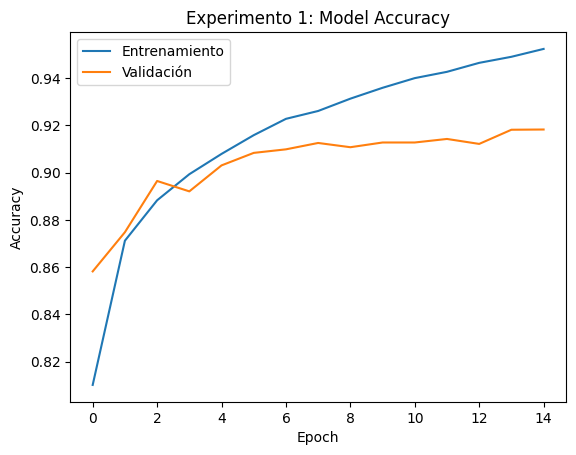

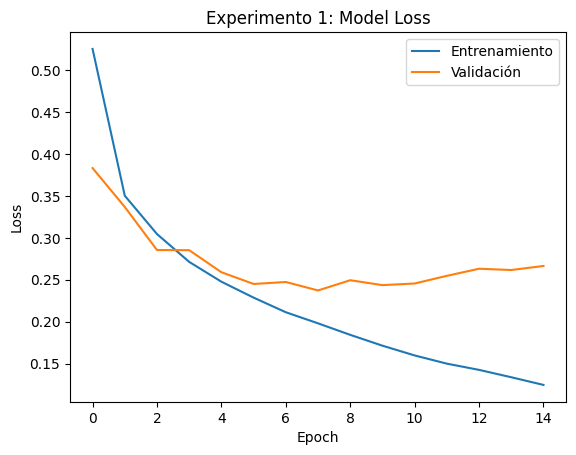

In [38]:
# 2. Dibujar las gráficas individuales de Accuracy y Loss
print("Gráficas del Experimento 1:")
plot_acc(history, title="Experimento 1: Model Accuracy")
plot_loss(history, title="Experimento 1: Model Loss")

### **Experimento 2**

#### 3) Se nos pide que la inialización de los parámetros sea "0" de todas las capas densas, y que añadamos una capa convolucional al modelo previamente definido. (1 punto)

In [39]:
from keras.initializers import Zeros

# 1. Definición de la arquitectura del Experimento 2
model_exp2 = Sequential([
    # Primera capa
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Segunda capa
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # TERCERA CAPA (Nueva capa convolucional solicitada)
    # Usamos padding='same' para no reducir excesivamente la dimensionalidad espacial
    Conv2D(128, (3, 3), activation='relu', padding='same'),

    Flatten(),

    # Capas densas con INICIALIZACIÓN A CERO
    Dense(128, activation='relu', kernel_initializer=Zeros(), bias_initializer=Zeros()),
    Dropout(0.3),
    Dense(10, activation='softmax', kernel_initializer=Zeros(), bias_initializer=Zeros())
])

# 2. Compilación
model_exp2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Entrenamiento
history_exp2 = model_exp2.fit(x_train, y_train,
                              epochs=15,
                              batch_size=64,
                              validation_data=(x_test, y_test),
                              callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0970 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026


#### 4) Realiza los siguientes puntos
4.1 Compara, mediante  tabla y gráfica, el modelo del ejercicio 3 con el del ejercicio 1. ¿ Cual ha tenido mejores métricas? (0.25 puntos)

4.2 ¿Cuál de los dos cambios introducidos en el ejercicio anterior (inicialización de parámetros o capa convolucional) crees que ha tenido mayor impacto en el rendimiento? (0.75 puntos)

In [40]:
# Registrar Experimento 2
registrar_experimento(mi_tabla, history_exp2, "Experimento 2", "CNN 3 capas + Init Zeros en Densas")

+---------------+--------------------------------------------+----------+--------+--------------+----------+
|  Experimento  |                Descripción                 | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+--------------------------------------------+----------+--------+--------------+----------+
| Experimento 1 | CNN Básica (32-64 filtros) con Dropout 0.3 |  0.9524  | 0.1247 |    0.9183    |  0.2665  |
| Experimento 2 |     CNN 3 capas + Init Zeros en Densas     |  0.0991  | 2.3027 |    0.1000    |  2.3026  |
+---------------+--------------------------------------------+----------+--------+--------------+----------+


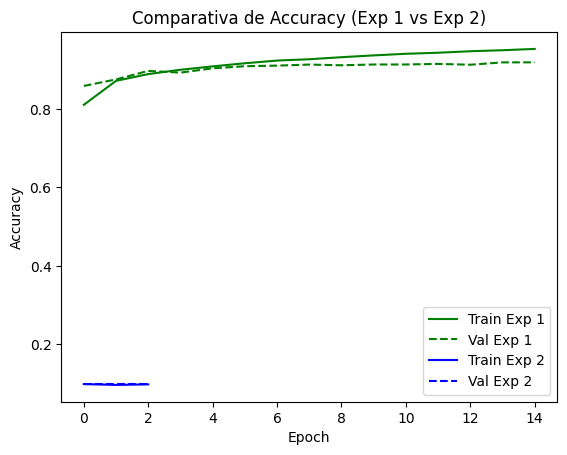

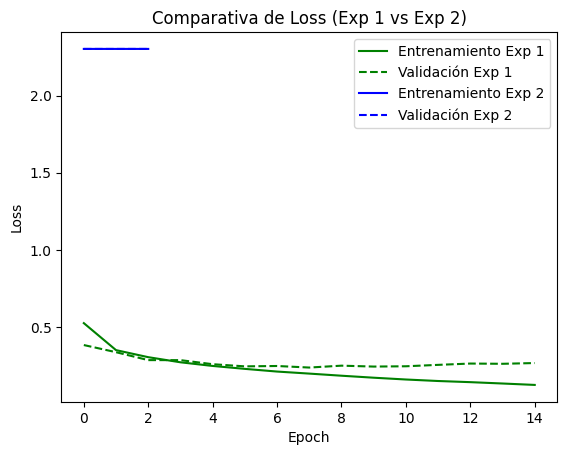

In [41]:
# Mostrar comparativa gráfica
plot_compare_accs(history, history_exp2, name1="Exp 1", name2="Exp 2", title="Comparativa de Accuracy (Exp 1 vs Exp 2)")
plot_compare_losses(history, history_exp2, name1="Exp 1", name2="Exp 2", title="Comparativa de Loss (Exp 1 vs Exp 2)")

4.1) Comparativa mediante tabla y gráfica (0.25 puntos)

El Experimento 1 tiene métricas abismalmente mejores. El modelo del Experimento 2 se queda estancado en un ~10% de accuracy (que equivale a adivinar al azar entre las 10 clases), y su función de pérdida no logra descender.

4.2) ¿Qué cambio tuvo mayor impacto en el rendimiento? (0.75 puntos)

El cambio que ha tenido un impacto catastrófico en el rendimiento ha sido la inicialización de los parámetros a "0" en las capas densas. Añadir una capa convolucional extra normalmente ayuda a extraer patrones más complejos (o, en el peor de los casos, no empeora dramáticamente el resultado), pero la inicialización a ceros destruye la capacidad de aprendizaje de la red.

Justificación teórica: Esto se debe al problema de la ruptura de la simetría (Symmetry Breaking). Si todos los pesos de una capa densa se inician a cero, todas las neuronas de esa capa realizarán exactamente el mismo cálculo y producirán la misma salida. Durante el backpropagation (propagación hacia atrás), los gradientes calculados para actualizar los pesos serán idénticos para todas las neuronas. Como resultado, todas las neuronas evolucionarán de la misma manera y aprenderán la misma característica, inutilizando por completo el propósito de tener múltiples neuronas y deteniendo el aprendizaje del modelo.

### **Experimento 3**

#### 5)  Se solicita procesar el dataset fashion_mnist para filtrar únicamente dos clases y crear un nuevo dataset:

- Clase 0: T-shirt/top
- Clase 1: Trouser

(1 punto)

In [42]:
# 1. Crear máscaras para el conjunto de entrenamiento (etiquetas 0 o 1)
mask_train = (y_train == 0) | (y_train == 1)
x_train_bin = x_train[mask_train]
y_train_bin = y_train[mask_train]

# 2. Crear máscaras para el conjunto de test (etiquetas 0 o 1)
mask_test = (y_test == 0) | (y_test == 1)
x_test_bin = x_test[mask_test]
y_test_bin = y_test[mask_test]

print("Nuevo x_train_bin shape:", x_train_bin.shape)
print("Nuevo y_train_bin shape:", y_train_bin.shape)
print("Clases únicas en y_train_bin:", np.unique(y_train_bin))

Nuevo x_train_bin shape: (12000, 28, 28, 1)
Nuevo y_train_bin shape: (12000,)
Clases únicas en y_train_bin: [0 1]


#### 6) Utiliza este nuevo dataset de dos clases con tu mejor modelo, donde previamente tienes que cambiar la función de pérdida a binary_crossentropy y cambia la capa de salida para que no utilice softmax. (1 punto)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9672 - loss: 0.0889 - val_accuracy: 0.9840 - val_loss: 0.0372
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9903 - loss: 0.0290 - val_accuracy: 0.9870 - val_loss: 0.0304
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 0.9925 - val_loss: 0.0183
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9950 - loss: 0.0147 - val_accuracy: 0.9905 - val_loss: 0.0181
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9959 - loss: 0.0138 - val_accuracy: 0.9945 - val_loss: 0.0158
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9930 - val_loss: 0.0150
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9970 - loss: 0.0092 - val_accuracy: 0.9935 - val_loss: 0.0141
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0086 - val_accuracy: 0

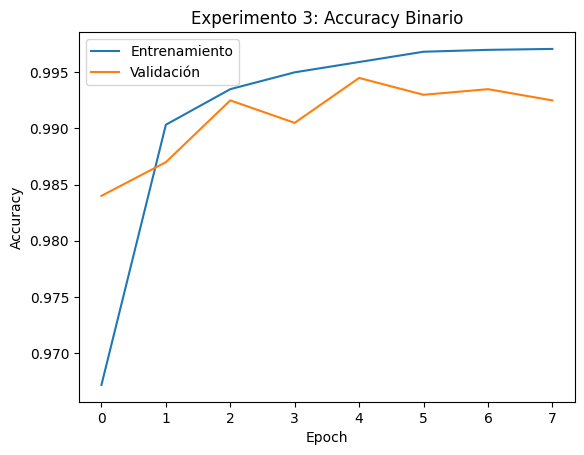

In [43]:
# 1. Definición del modelo basado en la mejor arquitectura (Exp 1)
model_binario = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # CAMBIO: 1 sola neurona con función de activación sigmoide (no softmax)
    Dense(1, activation='sigmoid')
])

# 2. Compilación con binary_crossentropy
model_binario.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# 3. Entrenamiento con el dataset filtrado
history_binario = model_binario.fit(x_train_bin, y_train_bin,
                                    epochs=15,
                                    batch_size=64,
                                    validation_data=(x_test_bin, y_test_bin),
                                    callbacks=[early_stop])

# Opcional: Registrar en la tabla para ver lo bien que funciona
registrar_experimento(mi_tabla, history_binario, "Experimento 3", "Clasificación Binaria (Clases 0 y 1)")
plot_acc(history_binario, title="Experimento 3: Accuracy Binario")

## **Problemas**

####9) Input de 256x256x64, con un tamaño de filtro 2 y un stripe de 2.

Calcular el nuevo volumen y los parámetros que produce de la capa Max Pooling (1 punto)

In [44]:
# Volumen de salida (W × H × D) --> (129x129x64)
# Número de parámetros          --> 0 parámetros

# Desarrollo / Cálculo:
# W_out = (W_in − F + 2P) / S + 1

# W = (256 - 2 + 2 * 0) / 2 + 1 = 254 / 2 + 1 = 127 + 1 = 128
# H = Como la imagen es cuadrada (256x256), H_out también es 128
# D = En Max Pooling la profundidad se mantiene igual, por lo que es 64

# Params → Max Pooling → 0

#### 10 ) A partir del grafo de computación de la figura aplica el algoritmo de backpropagation. (1 punto)



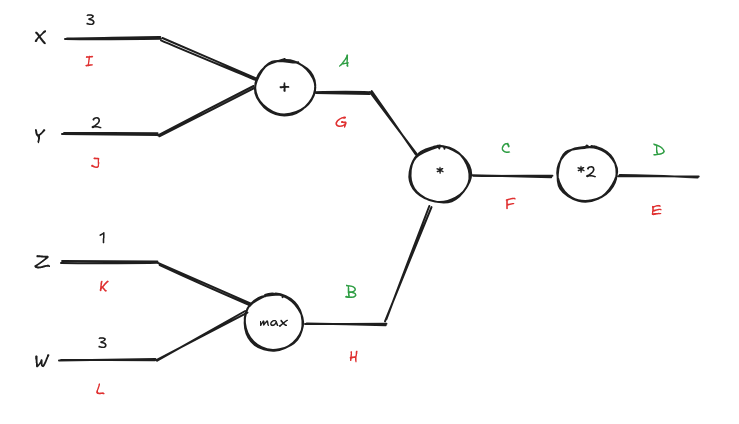

*  A: 5
*  B: 3
*  C: 15
*  D: 30
*  E: 1
*  F: 2
*  G: 6
*  H: 10
*  I: 6
*  J: 6
*  K: 0
*  L: 10
